AI/ML-BASED BAY OF BENGAL CARBON SINK ESTIMATION
BAY pCO2 + CO2 FLUX BASED PIPELINE

Original dataset:
(794172, 5)

Columns:
['Time', 'Lat', 'Lon', 'pCO2', 'flux']

DATA QUALITY CONTROL

Missing values before cleaning:
Date              0
Latitude          0
Longitude         0
pCO2         401635
flux         406290
dtype: int64

Dataset after QC:
(387882, 5)

Date range:
2015-01-31 00:00:00 → 2015-12-31 00:00:00

Available years:
[np.int32(2015)]

TARGET STATISTICS

pCO2:
count    387882.000000
mean        384.519000
std           8.978462
min         348.420100
25%         378.297558
50%         384.806080
75%         390.193645
max         454.813570
Name: pCO2, dtype: float64

CO2 Flux:
count    387882.000000
mean          0.033764
std           0.351146
min          -1.679162
25%          -0.197987
50%          -0.004648
75%           0.227324
max           5.532274
Name: flux, dtype: float64

FEATURE ENGINEERING
Features created successfully.

TARGET OUTLIER CONTROL
1st percenti

,Model,MAE,RMSE,R2
0,Extra Trees,0.254316,0.286904,-1.179168
1,HistGradientBoosting,0.280217,0.315037,-1.627486
2,Random Forest,0.295176,0.330053,-1.883926



Best model: Extra Trees

FEATURE IMPORTANCE


,Feature,Importance
3,Month,0.162160
4,DayOfYear,0.161080
10,pCO2_squared,0.125325
0,pCO2,0.109061
11,pCO2_deviation,0.107536
2,Longitude,0.078309
5,Month_sin,0.073733
7,DOY_sin,0.056982
8,DOY_cos,0.052665
6,Month_cos,0.039104



CARBON SINK / SOURCE SUMMARY

Observed:
Observed_State
Carbon Sink      73422
Carbon Source    22916
Name: count, dtype: int64

Predicted:
Predicted_State
Carbon Source    65364
Carbon Sink      30974
Name: count, dtype: int64

Predicted CO2 flux statistics:
count    96338.000000
mean         0.099587
std          0.212553
min         -0.537661
25%         -0.041834
50%          0.086670
75%          0.233205
max          0.929318
Name: Predicted_flux, dtype: float64


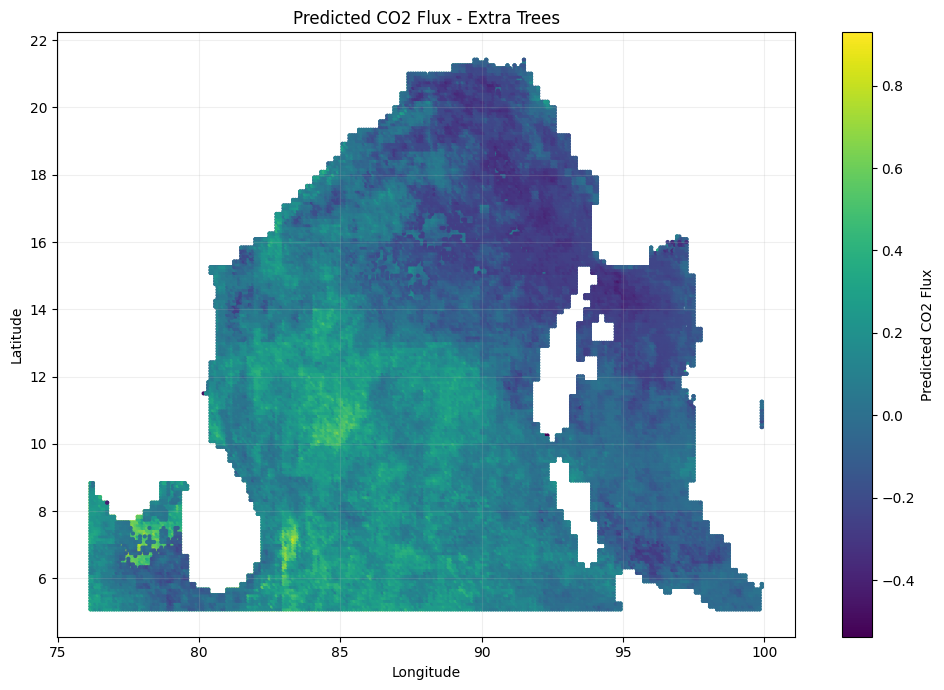

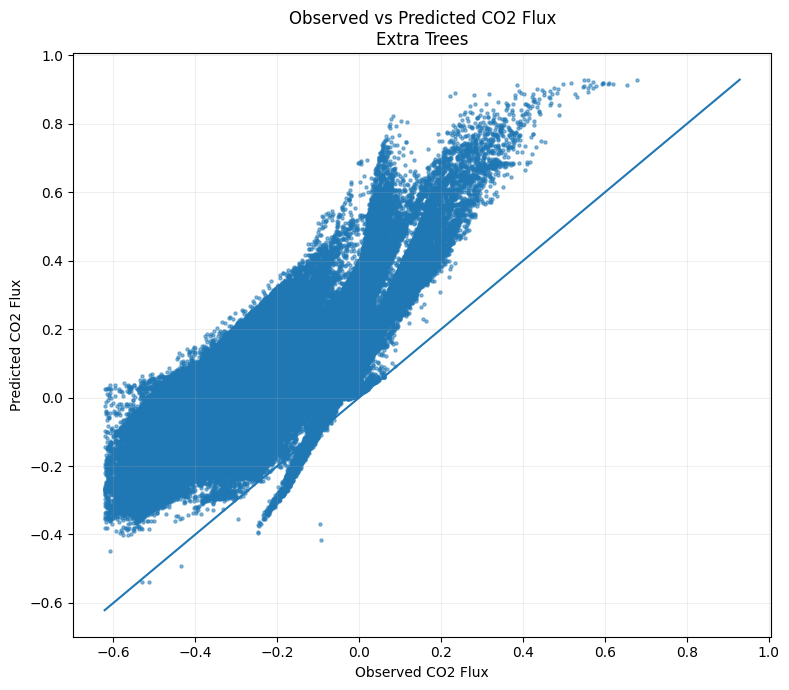

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

print("=" * 80)
print("AI/ML-BASED BAY OF BENGAL CARBON SINK ESTIMATION")
print("BAY pCO2 + CO2 FLUX BASED PIPELINE")
print("=" * 80)


# 1. LOAD DATA

FILE = "/content/Bay_of_Bengal_pCO2.csv"

if not os.path.exists(FILE):
    raise FileNotFoundError(
        f"File not found: {FILE}\n"
        "Please upload Bay_clean.csv to Colab."
    )

df = pd.read_csv(FILE, low_memory=False)

print("\nOriginal dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())



# 2. STANDARDIZE COLUMN NAMES


rename_map = {
    "Time": "Date",
    "time": "Date",
    "Lat": "Latitude",
    "lat": "Latitude",
    "Lon": "Longitude",
    "lon": "Longitude",
    "pco2": "pCO2",
    "PCO2": "pCO2",
    "co2_flux": "flux",
    "CO2_Flux": "flux"
}

df = df.rename(columns=rename_map)

required = [
    "Date",
    "Latitude",
    "Longitude",
    "pCO2",
    "flux"
]

missing = [c for c in required if c not in df.columns]

if missing:
    raise KeyError(
        f"Missing columns: {missing}\n"
        f"Available columns: {df.columns.tolist()}"
    )



# 3. DATA TYPE CONVERSION


df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

for col in [
    "Latitude",
    "Longitude",
    "pCO2",
    "flux"
]:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


# 4. DATA QUALITY CONTROL


print("\n" + "=" * 80)
print("DATA QUALITY CONTROL")
print("=" * 80)

print("\nMissing values before cleaning:")
print(df[required].isna().sum())

# Remove records without target
df = df.dropna(
    subset=[
        "Date",
        "Latitude",
        "Longitude",
        "pCO2",
        "flux"
    ]
).copy()

# Bay of Bengal approximate spatial boundary
df = df[
    (df["Latitude"] >= 5) &
    (df["Latitude"] <= 23) &
    (df["Longitude"] >= 75) &
    (df["Longitude"] <= 100)
].copy()

# Remove impossible coordinate values
df = df[
    (df["Latitude"].between(-90, 90)) &
    (df["Longitude"].between(-180, 180))
].copy()

print("\nDataset after QC:")
print(df.shape)



# 5. DATE INFORMATION


print("\nDate range:")
print(df["Date"].min(), "→", df["Date"].max())

print("\nAvailable years:")
print(
    sorted(
        df["Date"].dt.year.unique()
    )
)



# 6. TARGET STATISTICS

print("\n" + "=" * 80)
print("TARGET STATISTICS")
print("=" * 80)

print("\npCO2:")
print(df["pCO2"].describe())

print("\nCO2 Flux:")
print(df["flux"].describe())


# 7. FEATURE ENGINEERING


print("\n" + "=" * 80)
print("FEATURE ENGINEERING")
print("=" * 80)

# Temporal features
df["Month"] = df["Date"].dt.month
df["DayOfYear"] = df["Date"].dt.dayofyear
df["Day"] = df["Date"].dt.day

# Seasonal cyclic encoding
df["Month_sin"] = np.sin(
    2 * np.pi * df["Month"] / 12
)

df["Month_cos"] = np.cos(
    2 * np.pi * df["Month"] / 12
)

df["DOY_sin"] = np.sin(
    2 * np.pi * df["DayOfYear"] / 365.25
)

df["DOY_cos"] = np.cos(
    2 * np.pi * df["DayOfYear"] / 365.25
)

# Spatial interaction
df["Lat_Lon_Interaction"] = (
    df["Latitude"] *
    df["Longitude"]
)

# pCO2 transformations
df["pCO2_squared"] = (
    df["pCO2"] ** 2
)

df["pCO2_deviation"] = (
    df["pCO2"] -
    df["pCO2"].mean()
)

print("Features created successfully.")



# 8. REMOVE EXTREME OUTLIERS FROM TARGET


print("\n" + "=" * 80)
print("TARGET OUTLIER CONTROL")
print("=" * 80)

Q1 = df["flux"].quantile(0.01)
Q99 = df["flux"].quantile(0.99)

print("1st percentile :", Q1)
print("99th percentile:", Q99)

df_model = df[
    (df["flux"] >= Q1) &
    (df["flux"] <= Q99)
].copy()

print(
    "\nRows after target outlier control:",
    len(df_model)
)



# 9. FEATURES AND TARGET


FEATURES = [
    "pCO2",
    "Latitude",
    "Longitude",
    "Month",
    "DayOfYear",
    "Month_sin",
    "Month_cos",
    "DOY_sin",
    "DOY_cos",
    "Lat_Lon_Interaction",
    "pCO2_squared",
    "pCO2_deviation"
]

TARGET = "flux"

X = df_model[FEATURES].copy()
y = df_model[TARGET].copy()



# 10. TEMPORAL HOLDOUT


print("\n" + "=" * 80)
print("TRAIN / TEST SPLIT")
print("=" * 80)


dates = df_model["Date"]

cutoff = dates.quantile(0.80)

train_mask = dates < cutoff
test_mask = dates >= cutoff

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

print(
    "Training period:",
    dates.loc[train_mask].min(),
    "→",
    dates.loc[train_mask].max()
)

print(
    "Testing period :",
    dates.loc[test_mask].min(),
    "→",
    dates.loc[test_mask].max()
)



# 11. MODELS


models = {

    "Random Forest": RandomForestRegressor(
        n_estimators=150,
        max_depth=20,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=150,
        max_depth=20,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        random_state=42
    )
}



# 12. TRAIN + EVALUATE


results = []

predictions = {}

print("\n" + "=" * 80)
print("MODEL TRAINING")
print("=" * 80)

for name, model in models.items():

    print(f"\nTraining: {name}")

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(
        X_test
    )

    predictions[name] = pred

    mae = mean_absolute_error(
        y_test,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            pred
        )
    )

    r2 = r2_score(
        y_test,
        pred
    )

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    print(
        f"MAE  = {mae:.6f}"
    )

    print(
        f"RMSE = {rmse:.6f}"
    )

    print(
        f"R2   = {r2:.6f}"
    )


# 13. MODEL COMPARISON


results_df = pd.DataFrame(
    results
).sort_values(
    "RMSE"
).reset_index(drop=True)

print("\n" + "=" * 80)
print("MODEL COMPARISON")
print("=" * 80)

display(results_df)


# 14. SELECT BEST MODEL


best_model_name = results_df.iloc[0]["Model"]

best_model = models[
    best_model_name
]

best_prediction = predictions[
    best_model_name
]

print(
    "\nBest model:",
    best_model_name
)



# 15. FEATURE IMPORTANCE


print("\n" + "=" * 80)
print("FEATURE IMPORTANCE")
print("=" * 80)

if hasattr(
    best_model,
    "feature_importances_"
):

    importance = pd.DataFrame({
        "Feature": FEATURES,
        "Importance":
            best_model.feature_importances_
    }).sort_values(
        "Importance",
        ascending=False
    )

else:

    perm = permutation_importance(
        best_model,
        X_test,
        y_test,
        n_repeats=5,
        random_state=42,
        n_jobs=-1
    )

    importance = pd.DataFrame({
        "Feature": FEATURES,
        "Importance":
            perm.importances_mean
    }).sort_values(
        "Importance",
        ascending=False
    )

display(importance)



# 16. SAVE FEATURE IMPORTANCE


importance.to_csv(
    "/content/Feature_Importance.csv",
    index=False
)



# 17. CREATE PREDICTION DATASET


test_results = df_model.loc[
    test_mask,
    [
        "Date",
        "Latitude",
        "Longitude",
        "pCO2",
        "flux"
    ]
].copy()

test_results[
    "Predicted_flux"
] = best_prediction

test_results[
    "Flux_Error"
] = (
    test_results["flux"] -
    test_results["Predicted_flux"]
)

test_results[
    "Absolute_Error"
] = abs(
    test_results["Flux_Error"]
)



# 18. SINK / SOURCE CLASSIFICATION


# IMPORTANT:
# This assumes:
#   negative flux = CO2 uptake by ocean = carbon sink
#   positive flux = CO2 release = carbon source
#
# VERIFY THE SIGN CONVENTION OF YOUR ORIGINAL DATASET
# BEFORE USING THIS INTERPRETATION IN THE PAPER.

test_results[
    "Observed_State"
] = np.where(
    test_results["flux"] < 0,
    "Carbon Sink",
    "Carbon Source"
)

test_results[
    "Predicted_State"
] = np.where(
    test_results["Predicted_flux"] < 0,
    "Carbon Sink",
    "Carbon Source"
)



# 19. SAVE PREDICTIONS


prediction_file = (
    "/content/Bay_CO2_Flux_Predictions.csv"
)

test_results.to_csv(
    prediction_file,
    index=False
)



# 20. CARBON SINK / SOURCE SUMMARY


print("\n" + "=" * 80)
print("CARBON SINK / SOURCE SUMMARY")
print("=" * 80)

print("\nObserved:")
print(
    test_results[
        "Observed_State"
    ].value_counts()
)

print("\nPredicted:")
print(
    test_results[
        "Predicted_State"
    ].value_counts()
)



# 21. PREDICTED FLUX SUMMARY


print("\nPredicted CO2 flux statistics:")
print(
    test_results[
        "Predicted_flux"
    ].describe()
)



# 22. PREDICTED FLUX MAP


plt.figure(figsize=(10, 7))

plt.scatter(
    test_results["Longitude"],
    test_results["Latitude"],
    c=test_results["Predicted_flux"],
    s=4
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(
    f"Predicted CO2 Flux - {best_model_name}"
)

plt.colorbar(
    label="Predicted CO2 Flux"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    "/content/Predicted_CO2_Flux_Map.png",
    dpi=300
)

plt.show()



# 23. OBSERVED VS PREDICTED


plt.figure(figsize=(8, 7))

plt.scatter(
    y_test,
    best_prediction,
    s=5,
    alpha=0.5
)

minimum = min(
    y_test.min(),
    best_prediction.min()
)

maximum = max(
    y_test.max(),
    best_prediction.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum]
)

plt.xlabel("Observed CO2 Flux")
plt.ylabel("Predicted CO2 Flux")

plt.title(
    f"Observed vs Predicted CO2 Flux\n"
    f"{best_model_name}"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    "/content/Observed_vs_Predicted.png",
    dpi=300
)

plt.show()



# 24. SAVE MODEL RESULTS


results_df.to_csv(
    "/content/Model_Performance.csv",
    index=False
)


AI/ML-BASED BAY OF BENGAL CARBON SINK ESTIMATION
ABLATION STUDY

Pipeline variables found.
Training samples : 283786
Testing samples  : 96338
Features         : 12
Models to ablate : ['Extra Trees']

Feature groups:
  pCO2 block           (3): ['pCO2', 'pCO2_squared', 'pCO2_deviation']
  Spatial              (3): ['Latitude', 'Longitude', 'Lat_Lon_Interaction']
  Temporal (raw)       (2): ['Month', 'DayOfYear']
  Temporal (cyclic)    (4): ['Month_sin', 'Month_cos', 'DOY_sin', 'DOY_cos']

Experiments per model: 29

ABLATION: Extra Trees
Baseline fit: 66.5s  |  ~34.4 min for 29 experiments (+ 2 noise-floor fits)
Original pipeline RMSE = 0.286904 | ablation baseline RMSE = 0.286904 | difference = 0.00e+00
Seed noise (RMSE std) = 0.002003 | significance threshold = 0.004007
[ 1/29] 0. Baseline              All features                                       RMSE=0.28690  R2=-1.1792
[ 2/29] 1. Remove group          - pCO2 block                                       RMSE=0.37306  R2=-2.6845
[

,Experiment,N_Features,MAE,RMSE,R2,SinkSource_Acc,Delta_RMSE_%,Delta_R2,Effect
0,All features,12,0.254316,0.286904,-1.179168,0.559385,0.0,0.0,-



Extra Trees  |  1. Remove group


,Experiment,N_Features,MAE,RMSE,R2,SinkSource_Acc,Delta_RMSE_%,Delta_R2,Effect
0,- pCO2 block,9,0.310820,0.373061,-2.684489,0.523957,30.029918,-1.505321,Hurts when removed
1,- Temporal (cyclic),8,0.272298,0.308328,-1.516765,0.544095,7.467219,-0.337597,Hurts when removed
2,- Spatial,9,0.240792,0.269080,-0.916816,0.547998,-6.212521,0.262352,Improves when removed
3,- Temporal (raw),10,0.143905,0.171311,0.223059,0.790602,-40.289760,1.402226,Improves when removed



Extra Trees  |  2. Only group


...

,Experiment,N_Features,MAE,RMSE,R2,SinkSource_Acc,Delta_RMSE_%,Delta_R2,Effect
0,- Month_cos,11,0.261360,0.292773,-1.269231,0.550198,2.045528,-0.090063,Hurts when removed
1,- DOY_cos,11,0.258036,0.290122,-1.228317,0.564471,1.121430,-0.049150,No real change
2,- Latitude,11,0.247869,0.279845,-1.073246,0.577301,-2.460596,0.105922,Improves when removed
3,- pCO2,11,0.246421,0.279149,-1.062956,0.579252,-2.702963,0.116212,Improves when removed
4,- pCO2_deviation,11,0.246022,0.278881,-1.058993,0.576844,-2.796461,0.120175,Improves when removed
5,- pCO2_squared,11,0.242966,0.275437,-1.008448,0.580062,-3.996971,0.170720,Improves when removed
6,- Lat_Lon_Interaction,11,0.241797,0.273350,-0.978133,0.590722,-4.724239,0.201035,Improves when removed
7,- Longitude,11,0.241711,0.271954,-0.957973,0.579761,-5.210988,0.221195,Improves when removed
8,- Month_sin,11,0.235369,0.269036,-0.916184,0.589747,-6.227990,0.262984,Improves when removed
9,- DOY_sin,11,0.225202,0.257261,-0.752121,0.609593,-10.332160,0.427047,Improves when removed



Extra Trees  |  4. Engineering / blocks


,Experiment,N_Features,MAE,RMSE,R2,SinkSource_Acc,Delta_RMSE_%,Delta_R2,Effect
0,- ALL engineered transforms (raw features only),5,0.275958,0.312526,-1.585770,0.537493,8.930529,-0.406602,Hurts when removed
1,"- derived pCO2 (squared, deviation)",10,0.243987,0.277854,-1.043849,0.583031,-3.154583,0.135319,Improves when removed
2,- ALL spatial (pCO2 + temporal only),9,0.240792,0.269080,-0.916816,0.547998,-6.212521,0.262352,Improves when removed
3,- ALL temporal (pCO2 + spatial only),6,0.171007,0.214298,-0.215773,0.762274,-25.306824,0.963395,Improves when removed



Extra Trees  |  5. Cumulative add


,Experiment,N_Features,MAE,RMSE,R2,SinkSource_Acc,Delta_RMSE_%,Delta_R2,Effect
0,step 1: pCO2 block,3,0.166055,0.204110,-0.102922,0.754832,-28.857844,1.076246,-
1,step 2: + Spatial,6,0.171007,0.214298,-0.215773,0.762274,-25.306824,0.963395,-
2,step 3: + Temporal (raw),8,0.272298,0.308328,-1.516765,0.544095,7.467219,-0.337597,-
3,step 4: + Temporal (cyclic),12,0.254316,0.286904,-1.179168,0.559385,0.000000,0.000000,-


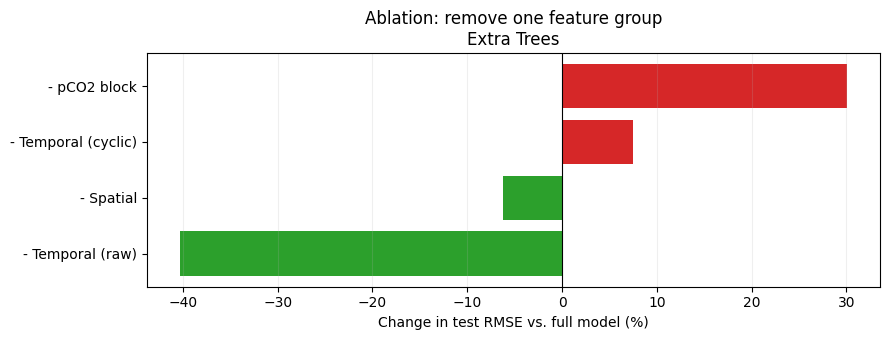

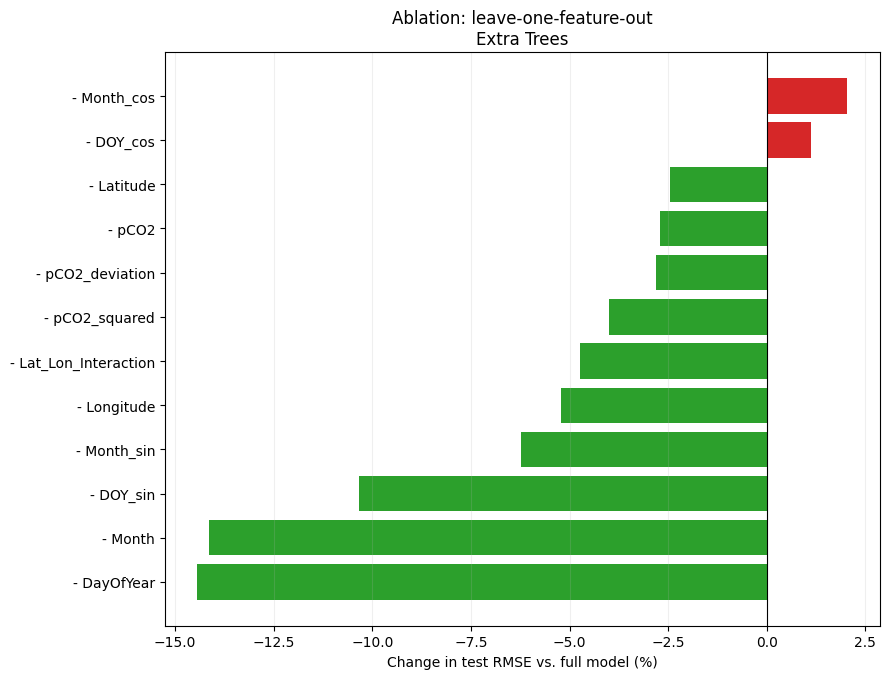

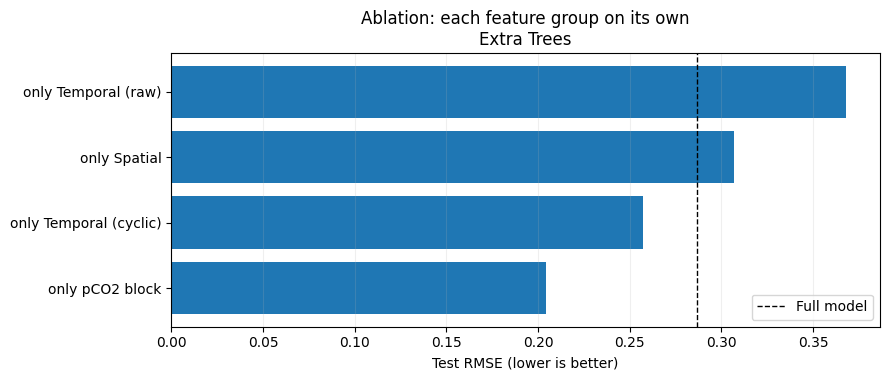

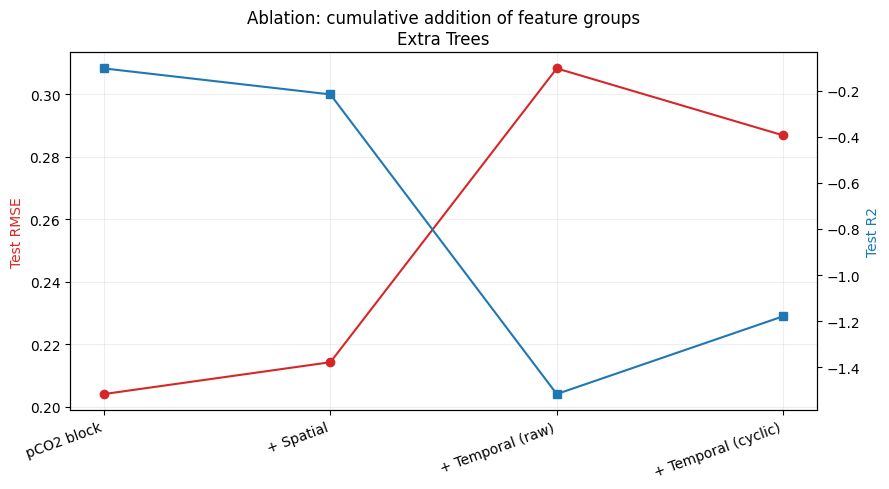


ABLATION SUMMARY

--- Extra Trees ---
Full model: RMSE=0.28690 | MAE=0.25432 | R2=-1.1792 | Sink/Source acc=0.5594
Seed noise (RMSE std) = 0.002003 | changes below 0.004007 RMSE are treated as noise

Group importance (RMSE increase when the group is removed):
  - pCO2 block               dRMSE = +0.08616 (+30.0%)   dR2 = -1.5053   [Hurts when removed]
  - Temporal (cyclic)        dRMSE = +0.02142 (+7.5%)   dR2 = -0.3376   [Hurts when removed]
  - Spatial                  dRMSE = -0.01782 (-6.2%)   dR2 = +0.2624   [Improves when removed]
  - Temporal (raw)           dRMSE = -0.11559 (-40.3%)   dR2 = +1.4022   [Improves when removed]

Most important single features (leave-one-out):
  - Month_cos                  dRMSE = +0.00587 (+2.0%)
  - DOY_cos                    dRMSE = +0.00322 (+1.1%)
  - Latitude                   dRMSE = -0.00706 (-2.5%)

Features whose individual removal makes no measurable difference
(may simply be duplicated by correlated features - check the GROUP results b

In [ ]:
import os
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# display() exists in Colab / Jupyter; fall back to print elsewhere
try:
    display
except NameError:
    display = print

print("=" * 80)
print("AI/ML-BASED BAY OF BENGAL CARBON SINK ESTIMATION")
print("ABLATION STUDY")
print("=" * 80)


# ================================================================
# A1. CONFIGURATION
# ================================================================

# Models to ablate.
#   [best_model_name]   -> only the best model from the pipeline (fast)
#   list(models.keys()) -> all three models (about 3x slower)
ABLATION_MODEL_NAMES = [best_model_name]

# Seed used by the original pipeline (random_state=42), so the
# baseline row reproduces the original test-set result exactly.
BASE_SEED = 42

# Extra seeds used ONLY to estimate the run-to-run noise floor of the
# full model (2 extra fits per model). A change in RMSE smaller than
# this noise floor should not be interpreted as a real effect.
NOISE_SEEDS = [43, 44]

# A change is flagged as "real" only if it is larger than
# max(2 x seed-std, MIN_REL_CHANGE x baseline RMSE)
MIN_REL_CHANGE = 0.01

# Output folder
ABLATION_DIR = "/content"
os.makedirs(ABLATION_DIR, exist_ok=True)


# ================================================================
# A2. CHECK THAT THE PIPELINE VARIABLES EXIST
# ================================================================

_required = [
    "df_model", "FEATURES", "TARGET",
    "X_train", "X_test", "y_train", "y_test",
    "models", "results_df", "best_model_name"
]

_missing = [v for v in _required if v not in globals()]

if _missing:
    raise RuntimeError(
        "Ablation study needs the variables created by the pipeline "
        f"above. Missing: {_missing}\n"
        "Run the pipeline cell (Bay pCO2 + CO2 Flux ML pipeline) first."
    )

for _m in ABLATION_MODEL_NAMES:
    if _m not in models:
        raise KeyError(
            f"Unknown model '{_m}'. Available: {list(models.keys())}"
        )

print("\nPipeline variables found.")
print("Training samples :", len(X_train))
print("Testing samples  :", len(X_test))
print("Features         :", len(FEATURES))
print("Models to ablate :", ABLATION_MODEL_NAMES)


# ================================================================
# A3. FEATURE GROUPS
# ================================================================

_GROUPS_DEFINITION = {

    "pCO2 block": [
        "pCO2",
        "pCO2_squared",
        "pCO2_deviation"
    ],

    "Spatial": [
        "Latitude",
        "Longitude",
        "Lat_Lon_Interaction"
    ],

    "Temporal (raw)": [
        "Month",
        "DayOfYear"
    ],

    "Temporal (cyclic)": [
        "Month_sin",
        "Month_cos",
        "DOY_sin",
        "DOY_cos"
    ]
}

# keep only features that are really in FEATURES
GROUPS = {
    g: [f for f in cols if f in FEATURES]
    for g, cols in _GROUPS_DEFINITION.items()
}

GROUPS = {g: cols for g, cols in GROUPS.items() if cols}

# any feature not covered goes to an "Other" group
_covered = [f for cols in GROUPS.values() for f in cols]
_other = [f for f in FEATURES if f not in _covered]

if _other:
    GROUPS["Other"] = _other

print("\nFeature groups:")
for g, cols in GROUPS.items():
    print(f"  {g:<20s} ({len(cols)}): {cols}")

# engineered transformations (everything that is not a raw variable)
ENGINEERED = [
    f for f in [
        "pCO2_squared",
        "pCO2_deviation",
        "Lat_Lon_Interaction",
        "Month_sin",
        "Month_cos",
        "DOY_sin",
        "DOY_cos"
    ] if f in FEATURES
]


# ================================================================
# A4. EXPERIMENT DEFINITIONS
# ================================================================

def build_experiments(all_features):

    exps = []

    # ------------------------------------------------------------
    # 0. Baseline
    # ------------------------------------------------------------
    exps.append((
        "0. Baseline",
        "All features",
        list(all_features)
    ))

    # ------------------------------------------------------------
    # 1. Leave one GROUP out
    # ------------------------------------------------------------
    for g, cols in GROUPS.items():
        exps.append((
            "1. Remove group",
            f"- {g}",
            [f for f in all_features if f not in cols]
        ))

    # ------------------------------------------------------------
    # 2. Keep ONLY one group
    # ------------------------------------------------------------
    for g, cols in GROUPS.items():
        exps.append((
            "2. Only group",
            f"only {g}",
            [f for f in all_features if f in cols]
        ))

    # ------------------------------------------------------------
    # 3. Leave one FEATURE out
    # ------------------------------------------------------------
    for f in all_features:
        exps.append((
            "3. Remove feature",
            f"- {f}",
            [c for c in all_features if c != f]
        ))

    # ------------------------------------------------------------
    # 4. Feature-engineering / block ablation
    # ------------------------------------------------------------
    derived_pco2 = [
        f for f in ["pCO2_squared", "pCO2_deviation"]
        if f in all_features
    ]

    if derived_pco2:
        exps.append((
            "4. Engineering / blocks",
            "- derived pCO2 (squared, deviation)",
            [f for f in all_features if f not in derived_pco2]
        ))

    if ENGINEERED:
        exps.append((
            "4. Engineering / blocks",
            "- ALL engineered transforms (raw features only)",
            [f for f in all_features if f not in ENGINEERED]
        ))

    temporal = (
        GROUPS.get("Temporal (raw)", []) +
        GROUPS.get("Temporal (cyclic)", [])
    )

    if temporal:
        exps.append((
            "4. Engineering / blocks",
            "- ALL temporal (pCO2 + spatial only)",
            [f for f in all_features if f not in temporal]
        ))

    spatial = GROUPS.get("Spatial", [])

    if spatial:
        exps.append((
            "4. Engineering / blocks",
            "- ALL spatial (pCO2 + temporal only)",
            [f for f in all_features if f not in spatial]
        ))

    # ------------------------------------------------------------
    # 5. Cumulative (forward) addition of groups
    # ------------------------------------------------------------
    order = [
        g for g in [
            "pCO2 block",
            "Spatial",
            "Temporal (raw)",
            "Temporal (cyclic)",
            "Other"
        ] if g in GROUPS
    ]

    used = []

    for i, g in enumerate(order):
        used += GROUPS[g]
        label = g if i == 0 else f"+ {g}"

        exps.append((
            "5. Cumulative add",
            f"step {i + 1}: {label}",
            [f for f in all_features if f in used]
        ))

    return exps


experiments = build_experiments(FEATURES)

print("\nExperiments per model:", len(experiments))


# ================================================================
# A5. TRAIN + EVALUATE ONE FEATURE SET
# ================================================================

_fit_cache = {}


def evaluate_feature_set(model_name, feature_list, seed=BASE_SEED):

    key = (model_name, tuple(sorted(feature_list)), seed)

    if key in _fit_cache:
        return _fit_cache[key]

    est = clone(models[model_name])
    est.set_params(random_state=seed)

    t0 = time.time()

    est.fit(
        X_train[feature_list],
        y_train
    )

    fit_seconds = time.time() - t0

    pred = est.predict(
        X_test[feature_list]
    )

    out = {
        "MAE": mean_absolute_error(y_test, pred),

        "RMSE": np.sqrt(
            mean_squared_error(y_test, pred)
        ),

        "R2": r2_score(y_test, pred),

        # sink / source agreement (same sign convention as pipeline:
        # flux < 0 -> carbon sink)
        "SinkSource_Acc": float(
            np.mean(
                (np.asarray(y_test) < 0) == (pred < 0)
            )
        ),

        "Fit_Seconds": fit_seconds
    }

    _fit_cache[key] = out

    return out


# ================================================================
# A6. RUN THE ABLATION
# ================================================================

all_rows = []
noise_info = {}

for model_name in ABLATION_MODEL_NAMES:

    print("\n" + "=" * 80)
    print("ABLATION:", model_name)
    print("=" * 80)

    n_exp = len(experiments)

    # ---------------- baseline first (also times one fit) --------
    base = evaluate_feature_set(
        model_name,
        list(FEATURES)
    )

    est_total = base["Fit_Seconds"] * (n_exp + len(NOISE_SEEDS))

    print(
        f"Baseline fit: {base['Fit_Seconds']:.1f}s  |  "
        f"~{est_total / 60:.1f} min for {n_exp} experiments "
        f"(+ {len(NOISE_SEEDS)} noise-floor fits)"
    )

    # sanity check vs. the original pipeline result
    ref = results_df[results_df["Model"] == model_name]

    if len(ref):
        ref_rmse = float(ref["RMSE"].iloc[0])
        print(
            f"Original pipeline RMSE = {ref_rmse:.6f} | "
            f"ablation baseline RMSE = {base['RMSE']:.6f} | "
            f"difference = {abs(ref_rmse - base['RMSE']):.2e}"
        )

    # ---------------- noise floor ---------------------------------
    noise_rmse = [base["RMSE"]]

    for s in NOISE_SEEDS:
        r = evaluate_feature_set(
            model_name,
            list(FEATURES),
            seed=s
        )
        noise_rmse.append(r["RMSE"])

    noise_std = float(np.std(noise_rmse, ddof=1)) if len(noise_rmse) > 1 else 0.0

    threshold = max(
        2 * noise_std,
        MIN_REL_CHANGE * base["RMSE"]
    )

    noise_info[model_name] = {
        "seed_rmse": noise_rmse,
        "seed_std": noise_std,
        "threshold": threshold
    }

    print(
        f"Seed noise (RMSE std) = {noise_std:.6f} | "
        f"significance threshold = {threshold:.6f}"
    )

    # ---------------- all experiments -----------------------------
    for i, (exp_type, exp_name, feats) in enumerate(experiments, start=1):

        res = evaluate_feature_set(
            model_name,
            feats
        )

        print(
            f"[{i:>2}/{n_exp}] {exp_type:<24s} "
            f"{exp_name:<50s} "
            f"RMSE={res['RMSE']:.5f}  R2={res['R2']:.4f}"
        )

        all_rows.append({
            "Model": model_name,
            "Experiment_Type": exp_type,
            "Experiment": exp_name,
            "N_Features": len(feats),
            "Features": ", ".join(feats),
            **res
        })


# ================================================================
# A7. DELTAS VS BASELINE
# ================================================================

ablation_df = pd.DataFrame(all_rows)

parts = []

for model_name, sub in ablation_df.groupby("Model", sort=False):

    sub = sub.copy()

    b = sub[sub["Experiment_Type"] == "0. Baseline"].iloc[0]

    sub["Delta_MAE"] = sub["MAE"] - b["MAE"]
    sub["Delta_RMSE"] = sub["RMSE"] - b["RMSE"]
    sub["Delta_RMSE_%"] = 100 * sub["Delta_RMSE"] / b["RMSE"]
    sub["Delta_R2"] = sub["R2"] - b["R2"]
    sub["Delta_SinkSource_Acc"] = (
        sub["SinkSource_Acc"] - b["SinkSource_Acc"]
    )

    thr = noise_info[model_name]["threshold"]

    def _verdict(d):
        if d > thr:
            return "Hurts when removed"
        if d < -thr:
            return "Improves when removed"
        return "No real change"

    # verdict only makes sense for "removal" experiments
    _removal_types = [
        "1. Remove group",
        "3. Remove feature",
        "4. Engineering / blocks"
    ]

    sub["Effect"] = np.where(
        sub["Experiment_Type"].isin(_removal_types),
        sub["Delta_RMSE"].apply(_verdict),
        "-"
    )

    parts.append(sub)

ablation_df = pd.concat(parts, ignore_index=True)

ablation_df.to_csv(
    os.path.join(ABLATION_DIR, "Ablation_Results_All.csv"),
    index=False
)


# ================================================================
# A8. PRINT RESULT TABLES
# ================================================================

_show_cols = [
    "Experiment",
    "N_Features",
    "MAE",
    "RMSE",
    "R2",
    "SinkSource_Acc",
    "Delta_RMSE_%",
    "Delta_R2",
    "Effect"
]

for model_name in ABLATION_MODEL_NAMES:

    sub_m = ablation_df[ablation_df["Model"] == model_name]

    for exp_type in sorted(sub_m["Experiment_Type"].unique()):

        print("\n" + "=" * 80)
        print(f"{model_name}  |  {exp_type}")
        print("=" * 80)

        t = sub_m[sub_m["Experiment_Type"] == exp_type]

        # rank feature-level / group-level tables by damage
        if exp_type in [
            "1. Remove group",
            "3. Remove feature",
            "4. Engineering / blocks"
        ]:
            t = t.sort_values("Delta_RMSE", ascending=False)

        display(
            t[_show_cols].reset_index(drop=True)
        )


# ================================================================
# A9. PLOTS
# ================================================================

def _slug(text):
    return (
        str(text)
        .replace(" ", "_")
        .replace("/", "_")
    )


def _delta_barh(t, title, path):

    t = t.sort_values("Delta_RMSE_%", ascending=True)

    colors = [
        "tab:red" if v > 0 else "tab:green"
        for v in t["Delta_RMSE_%"]
    ]

    plt.figure(figsize=(9, max(3.5, 0.45 * len(t) + 1.5)))

    plt.barh(
        t["Experiment"],
        t["Delta_RMSE_%"],
        color=colors
    )

    plt.axvline(0, color="black", linewidth=0.8)

    plt.xlabel("Change in test RMSE vs. full model (%)")
    plt.title(title)
    plt.grid(axis="x", alpha=0.2)
    plt.tight_layout()
    plt.savefig(path, dpi=300)
    plt.show()


for model_name in ABLATION_MODEL_NAMES:

    sub_m = ablation_df[ablation_df["Model"] == model_name]
    tag = _slug(model_name)
    base_row = sub_m[sub_m["Experiment_Type"] == "0. Baseline"].iloc[0]

    # ---- (a) remove one group --------------------------------
    t = sub_m[sub_m["Experiment_Type"] == "1. Remove group"]

    _delta_barh(
        t,
        f"Ablation: remove one feature group\n{model_name}",
        os.path.join(ABLATION_DIR, f"Ablation_Group_Removal_{tag}.png")
    )

    # ---- (b) remove one feature ------------------------------
    t = sub_m[sub_m["Experiment_Type"] == "3. Remove feature"]

    _delta_barh(
        t,
        f"Ablation: leave-one-feature-out\n{model_name}",
        os.path.join(ABLATION_DIR, f"Ablation_Feature_Removal_{tag}.png")
    )

    # ---- (c) only one group ----------------------------------
    t = sub_m[sub_m["Experiment_Type"] == "2. Only group"].sort_values("RMSE")

    plt.figure(figsize=(9, max(3.5, 0.6 * len(t) + 1.5)))

    plt.barh(
        t["Experiment"],
        t["RMSE"]
    )

    plt.axvline(
        base_row["RMSE"],
        color="black",
        linestyle="--",
        linewidth=1,
        label="Full model"
    )

    plt.xlabel("Test RMSE (lower is better)")
    plt.title(f"Ablation: each feature group on its own\n{model_name}")
    plt.legend()
    plt.grid(axis="x", alpha=0.2)
    plt.tight_layout()
    plt.savefig(
        os.path.join(ABLATION_DIR, f"Ablation_Only_Group_{tag}.png"),
        dpi=300
    )
    plt.show()

    # ---- (d) cumulative addition -----------------------------
    t = sub_m[sub_m["Experiment_Type"] == "5. Cumulative add"]

    fig, ax1 = plt.subplots(figsize=(9, 5))

    x = np.arange(len(t))

    ax1.plot(x, t["RMSE"], marker="o", color="tab:red", label="RMSE")
    ax1.set_ylabel("Test RMSE", color="tab:red")
    ax1.set_xticks(x)
    ax1.set_xticklabels(
        [e.split(": ", 1)[-1] for e in t["Experiment"]],
        rotation=20,
        ha="right"
    )

    ax2 = ax1.twinx()
    ax2.plot(x, t["R2"], marker="s", color="tab:blue", label="R2")
    ax2.set_ylabel("Test R2", color="tab:blue")

    ax1.set_title(f"Ablation: cumulative addition of feature groups\n{model_name}")
    ax1.grid(alpha=0.2)
    fig.tight_layout()
    fig.savefig(
        os.path.join(ABLATION_DIR, f"Ablation_Cumulative_{tag}.png"),
        dpi=300
    )
    plt.show()


# ================================================================
# A10. SUMMARY
# ================================================================

print("\n" + "=" * 80)
print("ABLATION SUMMARY")
print("=" * 80)

for model_name in ABLATION_MODEL_NAMES:

    sub_m = ablation_df[ablation_df["Model"] == model_name]
    base_row = sub_m[sub_m["Experiment_Type"] == "0. Baseline"].iloc[0]
    info = noise_info[model_name]

    print(f"\n--- {model_name} ---")

    print(
        f"Full model: RMSE={base_row['RMSE']:.5f} | "
        f"MAE={base_row['MAE']:.5f} | "
        f"R2={base_row['R2']:.4f} | "
        f"Sink/Source acc={base_row['SinkSource_Acc']:.4f}"
    )

    print(
        f"Seed noise (RMSE std) = {info['seed_std']:.6f} | "
        f"changes below {info['threshold']:.6f} RMSE are treated as noise"
    )

    grp = sub_m[
        sub_m["Experiment_Type"] == "1. Remove group"
    ].sort_values("Delta_RMSE", ascending=False)

    print("\nGroup importance (RMSE increase when the group is removed):")

    for _, r in grp.iterrows():
        print(
            f"  {r['Experiment']:<26s} "
            f"dRMSE = {r['Delta_RMSE']:+.5f} "
            f"({r['Delta_RMSE_%']:+.1f}%)   "
            f"dR2 = {r['Delta_R2']:+.4f}   [{r['Effect']}]"
        )

    feat = sub_m[
        sub_m["Experiment_Type"] == "3. Remove feature"
    ].sort_values("Delta_RMSE", ascending=False)

    print("\nMost important single features (leave-one-out):")

    for _, r in feat.head(3).iterrows():
        print(
            f"  {r['Experiment']:<28s} "
            f"dRMSE = {r['Delta_RMSE']:+.5f} ({r['Delta_RMSE_%']:+.1f}%)"
        )

    redundant = feat[feat["Effect"] != "Hurts when removed"]

    print(
        "\nFeatures whose individual removal makes no measurable difference"
        "\n(may simply be duplicated by correlated features - check the "
        "GROUP results before pruning):"
    )

    if len(redundant):
        for _, r in redundant.iterrows():
            print(
                f"  {r['Experiment']:<28s} "
                f"dRMSE = {r['Delta_RMSE']:+.5f} ({r['Delta_RMSE_%']:+.1f}%)  "
                f"[{r['Effect']}]"
            )
    else:
        print("  none - every single feature contributes")

print("\n" + "=" * 80)
print("HOW TO READ THE ABLATION RESULTS")
print("=" * 80)

print("""
- 'Remove group' / 'Remove feature': a large RMSE increase means the
  model depends on that information.
- 'Only group': how much a single block can explain on its own.
- 'Cumulative add': how performance grows as blocks are added.
- Features that are highly correlated (e.g. pCO2, pCO2_squared,
  pCO2_deviation or Month / Month_sin / Month_cos) can hide each
  other in leave-one-feature-out, so also check the GROUP results.
- The test set is the last 20% of the year (temporal holdout), so
  temporal features are evaluated on dates never seen in training.
- CO2 flux is normally computed from pCO2 (and wind / temperature),
  so a very large drop when the pCO2 block is removed is expected.
  State this clearly in the paper.
""")


# ================================================================
# A11. OUTPUT FILES
# ================================================================

print("=" * 80)
print("ABLATION COMPLETED")
print("=" * 80)

print("\nGenerated files:")

print(f"[OK] {os.path.join(ABLATION_DIR, 'Ablation_Results_All.csv')}")

for model_name in ABLATION_MODEL_NAMES:

    tag = _slug(model_name)

    for prefix in [
        "Ablation_Group_Removal",
        "Ablation_Feature_Removal",
        "Ablation_Only_Group",
        "Ablation_Cumulative"
    ]:
        print(f"[OK] {os.path.join(ABLATION_DIR, f'{prefix}_{tag}.png')}")

print("\nDONE.")